In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error

ratings = pd.read_csv('../data/ml-100k/u.data', sep='\t', names=['user_id', 'item_id', 'rating', 'timestamp'])
ratings_sorted = ratings.sort_values('timestamp').reset_index(drop=True)

n = len(ratings_sorted)
train_end = int(0.7 * n)
val_end = int(0.8 * n)
train_df = ratings_sorted.iloc[:train_end].copy()
val_df = ratings_sorted.iloc[train_end:val_end].copy()
test_df = ratings_sorted.iloc[val_end:].copy()
global_mean = train_df['rating'].mean()

genre_cols = ['unknown','Action','Adventure','Animation','Children','Comedy','Crime','Documentary','Drama','Fantasy','Film-Noir','Horror','Musical','Mystery',
              'Romance','Sci-Fi','Thriller','War','Western']
item_cols = ['item_id','title','release_date','video_date','imdb_url'] + genre_cols

movies = pd.read_csv('../data/ml-100k/u.item', sep='|', names=item_cols, encoding='latin-1')
movies[genre_cols] = movies[genre_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

print(f'Фильмов: {len(movies)}')
print(movies[['item_id','title','release_date'] + genre_cols[:5]].head())

Фильмов: 1682
   item_id              title release_date  unknown  Action  Adventure  \
0        1   Toy Story (1995)  01-Jan-1995        0       0          0   
1        2   GoldenEye (1995)  01-Jan-1995        0       1          1   
2        3  Four Rooms (1995)  01-Jan-1995        0       0          0   
3        4  Get Shorty (1995)  01-Jan-1995        0       1          0   
4        5     Copycat (1995)  01-Jan-1995        0       0          0   

   Animation  Children  
0          1         1  
1          0         0  
2          0         0  
3          0         0  
4          0         0  


# Feature engineering

In [2]:
movies['year'] = pd.to_datetime(movies['release_date'], format='%d-%b-%Y', errors='coerce').dt.year
movies['year'] = movies['year'].fillna(movies['year'].median())

print(movies[['title', 'year']].head())
print(f'Диапозон годов: {movies['year'].min():.0f} - {movies['year'].max():.0f}')

               title    year
0   Toy Story (1995)  1995.0
1   GoldenEye (1995)  1995.0
2  Four Rooms (1995)  1995.0
3  Get Shorty (1995)  1995.0
4     Copycat (1995)  1995.0
Диапозон годов: 1922 - 1998


In [3]:
item_stats = train_df.groupby('item_id')['rating'].agg(['mean', 'count'])
item_stats.columns = ['item_mean_rating', 'item_popularity']

user_stats = train_df.groupby('user_id')['rating'].agg(['mean', 'count'])
user_stats.columns = ['user_mean_rating', 'user_activity']

item_stats['item_popularity_log'] = np.log1p(item_stats['item_popularity']) # моя идея логарифмирования из EDA
user_stats['user_activity_log'] = np.log1p(user_stats['user_activity'])

print(item_stats.head())
print(user_stats.head())

         item_mean_rating  item_popularity  item_popularity_log
item_id                                                        
1                3.906433              342             5.837730
2                3.301075               93             4.543295
3                3.027778               72             4.290459
4                3.506579              152             5.030438
5                3.323077               65             4.189655
         user_mean_rating  user_activity  user_activity_log
user_id                                                    
1                3.596838            253           5.537334
5                2.874286            175           5.170484
6                3.635071            211           5.356586
8                3.796610             59           4.094345
9                4.272727             22           3.135494


In [4]:
print(movies[genre_cols].dtypes.unique())

[dtype('int64')]


In [5]:
train_with_genres = train_df.merge(movies[['item_id']+ genre_cols], on='item_id', how='left')
genre_mean_rating = {}

for g in genre_cols:
    mask = train_with_genres[g] == 1
    genre_mean_rating[g] = train_with_genres.loc[mask, 'rating'].mean() if mask.sum() > 0 else global_mean
genre_mean_rating = pd.Series(genre_mean_rating)

def expected_rating_by_genres(row):
    active = [g for g in genre_cols if row[g] == 1]
    return np.mean([genre_mean_rating[g] for g in active]) if active else global_mean

movies['genre_expected_rating'] = movies.apply(expected_rating_by_genres, axis=1)

print(genre_mean_rating.sort_values(ascending=False).round(3))
print(movies[['title', 'genre_expected_rating']].head())

Film-Noir      3.907
War            3.825
Drama          3.691
Documentary    3.666
Crime          3.656
Mystery        3.647
Romance        3.637
Western        3.593
Sci-Fi         3.580
Animation      3.573
Thriller       3.520
Musical        3.514
Adventure      3.503
Action         3.493
Comedy         3.399
Children       3.329
Horror         3.269
Fantasy        3.215
unknown        3.200
dtype: float64
               title  genre_expected_rating
0   Toy Story (1995)               3.433443
1   GoldenEye (1995)               3.505383
2  Four Rooms (1995)               3.520093
3  Get Shorty (1995)               3.527566
4     Copycat (1995)               3.622515


In [6]:
year_median = movies['year'].median()

print(f"global_mean = {global_mean:.4f}")
print(f"year_median = {year_median:.0f}")

global_mean = 3.5300
year_median = 1995


Теперь заполним информацию о пользователях с помощью таблицы u.user

In [7]:
user_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv('../data/ml-100k/u.user', sep='|', names=user_cols, encoding='latin-1')

print(users.head())
print(f'Професий: {users['occupation'].nunique()}')

users['gender_M'] = (users['gender'] == 'M').astype(int)
occ_dummies = pd.get_dummies(users['occupation'], prefix='occ').astype(int)
users = pd.concat([users, occ_dummies], axis=1)

demo_cols = ['age', 'gender_M'] + list(occ_dummies.columns)

users_features = users[['user_id'] + demo_cols]
print("Демо-признаков:", len(demo_cols))
print(users_features.head())

   user_id  age gender  occupation zip_code
0        1   24      M  technician    85711
1        2   53      F       other    94043
2        3   23      M      writer    32067
3        4   24      M  technician    43537
4        5   33      F       other    15213
Професий: 21
Демо-признаков: 23
   user_id  age  gender_M  occ_administrator  occ_artist  occ_doctor  \
0        1   24         1                  0           0           0   
1        2   53         0                  0           0           0   
2        3   23         1                  0           0           0   
3        4   24         1                  0           0           0   
4        5   33         0                  0           0           0   

   occ_educator  occ_engineer  occ_entertainment  occ_executive  ...  \
0             0             0                  0              0  ...   
1             0             0                  0              0  ...   
2             0             0                  0       

In [8]:
def build_features(df):
    d = df.merge(movies[['item_id', 'year', 'genre_expected_rating']+ genre_cols], on='item_id', how='left')
    d = d.merge(item_stats, on='item_id', how='left')
    d = d.merge(user_stats, on='user_id', how='left')
    d = d.merge(users_features, on='user_id', how='left')

    d['item_mean_rating'] = d['item_mean_rating'].fillna(d['genre_expected_rating']).fillna(global_mean)
    d['user_mean_rating'] = d['user_mean_rating'].fillna(global_mean)

    for col in ['item_popularity', 'user_activity', 'item_popularity_log', 'user_activity_log']:
        d[col] = d[col].fillna(0)

    d['year'] = d['year'].fillna(year_median)
    for g in genre_cols:
        d[g] = d[g].fillna(0)

    d['age'] = d['age'].fillna(users['age'].median())
    d['gender_M'] = d['gender_M'].fillna(0)

    for c in occ_dummies.columns:
        d[c] = d[c].fillna(0)

    feature_cols = (genre_cols + ['year', 'item_mean_rating', 'user_mean_rating',
                                 'item_popularity_log', 'user_activity_log'] + demo_cols)
    X = d[feature_cols].astype(float)
    y = d['rating'].astype(float)
    return X, y

X_train, y_train = build_features(train_df)
X_val, y_val = build_features(val_df)
X_test, y_test = build_features(test_df)


print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)
print(X_train.head())

assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
print("Пропусков нет")

X_train: (70000, 47) | X_val: (10000, 47) | X_test: (20000, 47)
   unknown  Action  Adventure  Animation  Children  Comedy  Crime  \
0      0.0     0.0        0.0        0.0       0.0     1.0    0.0   
1      0.0     0.0        0.0        0.0       0.0     0.0    0.0   
2      0.0     1.0        0.0        0.0       0.0     0.0    0.0   
3      0.0     0.0        0.0        0.0       0.0     0.0    0.0   
4      0.0     1.0        1.0        0.0       0.0     1.0    0.0   

   Documentary  Drama  Fantasy  ...  occ_marketing  occ_none  occ_other  \
0          0.0    0.0      0.0  ...            0.0       0.0        0.0   
1          0.0    1.0      0.0  ...            0.0       0.0        0.0   
2          0.0    0.0      0.0  ...            0.0       0.0        0.0   
3          0.0    0.0      0.0  ...            0.0       0.0        0.0   
4          0.0    0.0      0.0  ...            0.0       0.0        0.0   

   occ_programmer  occ_retired  occ_salesman  occ_scientist  occ_stude

Первая модель Ridge

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

def rmse_of(model, X, y):
    return root_mean_squared_error(y, model.predict(X))

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
results = []

for a in alphas:
    pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=a))])
    pipe.fit(X_train, y_train)
    train_rmse = rmse_of(pipe, X_train, y_train)
    val_rmse = rmse_of(pipe, X_val, y_val)
    results.append({'alpha': a, 'train_rmse': train_rmse, 'val_rmse': val_rmse})
    print(f"alpha={a:>7}:  train={train_rmse:.4f}   val={val_rmse:.4f}")

results_df = pd.DataFrame(results)
best_alpha = results_df.loc[results_df['val_rmse'].idxmin(), 'alpha']
print(f"\nЛучший alpha по val: {best_alpha}")

ridge_pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=best_alpha))])
ridge_pipe.fit(X_train, y_train)

ridge_test_rmse = rmse_of(ridge_pipe, X_test, y_test)
print(f"Ridge TEST RMSE: {ridge_test_rmse:.4f}")
print(f"Item mean baseline: 1.0367")
print(f"Улучшение: {1.0367 - ridge_test_rmse:+.4f}")

alpha=   0.01:  train=0.9250   val=1.0279
alpha=    0.1:  train=0.9250   val=1.0279
alpha=    1.0:  train=0.9250   val=1.0279
alpha=   10.0:  train=0.9250   val=1.0279
alpha=  100.0:  train=0.9250   val=1.0278

Лучший alpha по val: 100.0
Ridge TEST RMSE: 1.0507
Item mean baseline: 1.0367
Улучшение: -0.0140


**Регуляризация не улучшила результат**, потому что модель не переобучалась (признаков мало относительно объёма данных) - L2 проявился бы сильнее при большом числе признаков или малой выборке. Однако главное что **разрыв между результатами train - val - test уменьшился по сравнению с CF - моделями**, это значит что **feature engineering сработал** и проблема новых пользователей в тестовой выборке начала сжиматься

Посмотрим какие признаки самые информативные

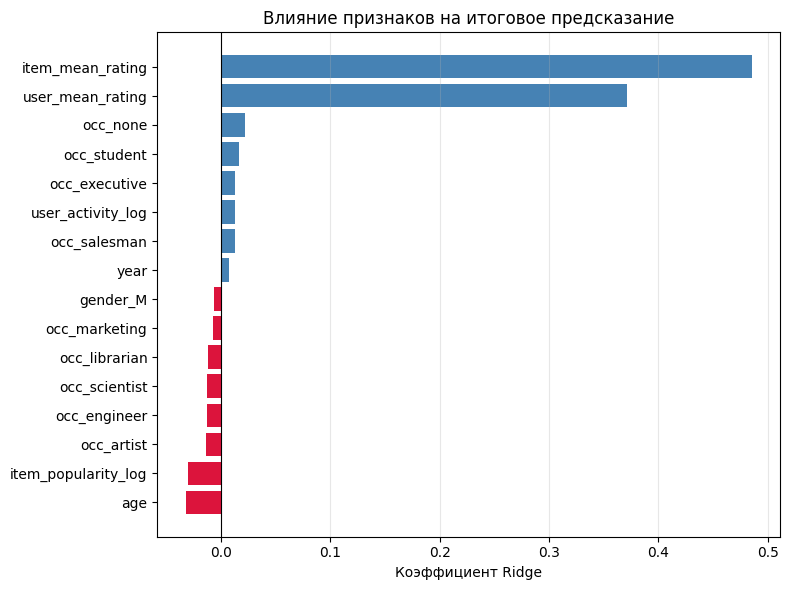

In [10]:
feature_cols = X_train.columns.tolist()
ridge = ridge_pipe.named_steps['ridge']
coefs = pd.Series(ridge.coef_, index=feature_cols).sort_values()

import matplotlib.pyplot as plt
top = pd.concat([coefs.head(8), coefs.tail(8)])
colors = ['crimson' if v < 0 else 'steelblue' for v in top.values]

plt.figure(figsize=(8, 6))
plt.barh(top.index, top.values, color=colors)
plt.xlabel('Коэффициент Ridge')
plt.title('Влияние признаков на итоговое предсказание')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Модель держится на item_mean_rating и user_mean_rating; остальные признаки, включая демографию, имеют коэффициенты около нуля и содержательно почти не влияют. Интерпретировать их знаки по отдельности рискованно из-за коллинеарности - для честной оценки важности лучше SHAP, который учитывает взаимодействия